## Phol Castañeda Henao, Neithan Gómez Rivera y Daniela Higuita Agudelo

### 1.	Carga y comprensión de los datos:

a.	Carguen el archivo de datos en Pandas.

In [226]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

ROOT_DIR = Path().resolve().parent
DATA_DIR = ROOT_DIR / "data/raw"
file_path = 'nyc-rolling-sales.csv' 



df = pd.read_csv(DATA_DIR / file_path,
    # na_values=[' ',' -  ']

) 
df

,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,,C2,153 AVENUE B,...,5,0,5,1633,6440,1900,2,C2,6625000,2017-07-19 00:00:00
1,5,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,26,,C7,234 EAST 4TH STREET,...,28,3,31,4616,18690,1900,2,C7,-,2016-12-14 00:00:00
2,6,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,39,,C7,197 EAST 3RD STREET,...,16,1,17,2212,7803,1900,2,C7,-,2016-12-09 00:00:00
3,7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,,C4,154 EAST 7TH STREET,...,10,0,10,2272,6794,1913,2,C4,3936272,2016-09-23 00:00:00
4,8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,,C2,301 EAST 10TH STREET,...,6,0,6,2369,4615,1900,2,C2,8000000,2016-11-17 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84543,8409,5,WOODROW,02 TWO FAMILY DWELLINGS,1,7349,34,,B9,37 QUAIL LANE,...,2,0,2,2400,2575,1998,1,B9,450000,2016-11-28 00:00:00
84544,8410,5,WOODROW,02 TWO FAMILY DWELLINGS,1,7349,78,,B9,32 PHEASANT LANE,...,2,0,2,2498,2377,1998,1,B9,550000,2017-04-21 00:00:00
84545,8411,5,WOODROW,02 TWO FAMILY DWELLINGS,1,7351,60,,B2,49 PITNEY AVENUE,...,2,0,2,4000,1496,1925,1,B2,460000,2017-07-05 00:00:00
84546,8412,5,WOODROW,22 STORE BUILDINGS,4,7100,28,,K6,2730 ARTHUR KILL ROAD,...,0,7,7,208033,64117,2001,4,K6,11693337,2016-12-21 00:00:00


b. Indique cuántas variables y registros tiene el dataframe, y asegúrense de que el tipo de dato de cada variable sea el esperado.

- El dataframe tiene 22 variables y 84548 registros.

- La primera columna 'Unnamed: 0' si tiene el tipo de dato correcto pero al no tener nombre no se sabe a que hace referencia, por lo que será eliminada.

- La variable EASE-MENT tiene como tipo object pero todos los registros están vacíos en esa columna, por lo que será eliminada.

- Las variables LAND SQUARE FEET, GROSS SQUARE FEET y SALE PRICE no tienen el tipo de dato correcto, ya que deberían ser tipo int64 , pero al tener valores nulos ' -  ' las toma como tipo objeto.

- La variable SALE DATE tiene tipo object pero debería convertirse a tipo datetime.

- El resto de las variables tienen el tipo de dato correcto.


In [227]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84548 entries, 0 to 84547
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Unnamed: 0                      84548 non-null  int64 
 1   BOROUGH                         84548 non-null  int64 
 2   NEIGHBORHOOD                    84548 non-null  object
 3   BUILDING CLASS CATEGORY         84548 non-null  object
 4   TAX CLASS AT PRESENT            84548 non-null  object
 5   BLOCK                           84548 non-null  int64 
 6   LOT                             84548 non-null  int64 
 7   EASE-MENT                       84548 non-null  object
 8   BUILDING CLASS AT PRESENT       84548 non-null  object
 9   ADDRESS                         84548 non-null  object
 10  APARTMENT NUMBER                84548 non-null  object
 11  ZIP CODE                        84548 non-null  int64 
 12  RESIDENTIAL UNITS               84548 non-null

Cargando correctamente el dataset aplicando na_values

In [228]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

ROOT_DIR = Path().resolve().parent
DATA_DIR = ROOT_DIR / "data/raw"
file_path = 'nyc-rolling-sales.csv' 



df = pd.read_csv(DATA_DIR / file_path,
    na_values=[' ',' -  ']

) 
df

,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,NaN,C2,153 AVENUE B,...,5,0,5,1633.0,6440.0,1900,2,C2,6625000.0,2017-07-19 00:00:00
1,5,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,26,NaN,C7,234 EAST 4TH STREET,...,28,3,31,4616.0,18690.0,1900,2,C7,NaN,2016-12-14 00:00:00
2,6,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,39,NaN,C7,197 EAST 3RD STREET,...,16,1,17,2212.0,7803.0,1900,2,C7,NaN,2016-12-09 00:00:00
3,7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,NaN,C4,154 EAST 7TH STREET,...,10,0,10,2272.0,6794.0,1913,2,C4,3936272.0,2016-09-23 00:00:00
4,8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,NaN,C2,301 EAST 10TH STREET,...,6,0,6,2369.0,4615.0,1900,2,C2,8000000.0,2016-11-17 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84543,8409,5,WOODROW,02 TWO FAMILY DWELLINGS,1,7349,34,NaN,B9,37 QUAIL LANE,...,2,0,2,2400.0,2575.0,1998,1,B9,450000.0,2016-11-28 00:00:00
84544,8410,5,WOODROW,02 TWO FAMILY DWELLINGS,1,7349,78,NaN,B9,32 PHEASANT LANE,...,2,0,2,2498.0,2377.0,1998,1,B9,550000.0,2017-04-21 00:00:00
84545,8411,5,WOODROW,02 TWO FAMILY DWELLINGS,1,7351,60,NaN,B2,49 PITNEY AVENUE,...,2,0,2,4000.0,1496.0,1925,1,B2,460000.0,2017-07-05 00:00:00
84546,8412,5,WOODROW,22 STORE BUILDINGS,4,7100,28,NaN,K6,2730 ARTHUR KILL ROAD,...,0,7,7,208033.0,64117.0,2001,4,K6,11693337.0,2016-12-21 00:00:00


In [229]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84548 entries, 0 to 84547
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      84548 non-null  int64  
 1   BOROUGH                         84548 non-null  int64  
 2   NEIGHBORHOOD                    84548 non-null  object 
 3   BUILDING CLASS CATEGORY         84548 non-null  object 
 4   TAX CLASS AT PRESENT            83810 non-null  object 
 5   BLOCK                           84548 non-null  int64  
 6   LOT                             84548 non-null  int64  
 7   EASE-MENT                       0 non-null      float64
 8   BUILDING CLASS AT PRESENT       83810 non-null  object 
 9   ADDRESS                         84548 non-null  object 
 10  APARTMENT NUMBER                19052 non-null  object 
 11  ZIP CODE                        84548 non-null  int64  
 12  RESIDENTIAL UNITS               

c. Reporten las estadísticas descriptivas de las variables numéricas y categóricas

###### Estadísticas descriptivas de las variables numéricas:

In [230]:
df.describe()

,Unnamed: 0,BOROUGH,BLOCK,LOT,EASE-MENT,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,SALE PRICE
count,84548.000000,84548.000000,84548.000000,84548.000000,0.0,84548.000000,84548.000000,84548.000000,84548.000000,5.829600e+04,5.693600e+04,84548.000000,84548.000000,6.998700e+04
mean,10344.359878,2.998758,4237.218976,376.224015,NaN,10731.991614,2.025264,0.193559,2.249184,3.941676e+03,4.045707e+03,1789.322976,1.657485,1.276456e+06
std,7151.779436,1.289790,3568.263407,658.136814,NaN,1290.879147,16.721037,8.713183,18.972584,4.198397e+04,3.503249e+04,537.344993,0.819341,1.140526e+07
min,4.000000,1.000000,1.000000,1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000,0.000000e+00
25%,4231.000000,2.000000,1322.750000,22.000000,NaN,10305.000000,0.000000,0.000000,1.000000,1.650000e+03,1.046750e+03,1920.000000,1.000000,2.250000e+05
50%,8942.000000,3.000000,3311.000000,50.000000,NaN,11209.000000,1.000000,0.000000,1.000000,2.325000e+03,1.680000e+03,1940.000000,2.000000,5.300000e+05
75%,15987.250000,4.000000,6281.000000,1001.000000,NaN,11357.000000,2.000000,0.000000,2.000000,3.500000e+03,2.560000e+03,1965.000000,2.000000,9.500000e+05
max,26739.000000,5.000000,16322.000000,9106.000000,NaN,11694.000000,1844.000000,2261.000000,2261.000000,4.252327e+06,3.750565e+06,2017.000000,4.000000,2.210000e+09


###### Estadísticas descriptivas de las variables categóricas:

In [231]:
df.describe(include='object')

,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,BUILDING CLASS AT TIME OF SALE,SALE DATE
count,84548,84548,83810,83810,84548,19052,84548,84548
unique,254,47,10,166,67563,3988,166,364
top,FLUSHING-NORTH,01 ONE FAMILY DWELLINGS,1,D4,131-05 40TH ROAD,4,R4,2017-06-29 00:00:00
freq,3068,18235,38633,12663,210,298,12989,544


d.	Identifiquen si el dataframe tiene datos duplicados.

In [232]:
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  0


e. Identifiquen si hay variables con valores nulos.

In [233]:
df.isnull().sum().sort_values(ascending=False)*100/df.shape[0]

EASE-MENT                         100.000000
APARTMENT NUMBER                   77.466055
GROSS SQUARE FEET                  32.658372
LAND SQUARE FEET                   31.049818
SALE PRICE                         17.222170
TAX CLASS AT PRESENT                0.872877
BUILDING CLASS AT PRESENT           0.872877
BLOCK                               0.000000
NEIGHBORHOOD                        0.000000
BOROUGH                             0.000000
Unnamed: 0                          0.000000
BUILDING CLASS CATEGORY             0.000000
ADDRESS                             0.000000
LOT                                 0.000000
COMMERCIAL UNITS                    0.000000
RESIDENTIAL UNITS                   0.000000
ZIP CODE                            0.000000
TOTAL UNITS                         0.000000
YEAR BUILT                          0.000000
TAX CLASS AT TIME OF SALE           0.000000
BUILDING CLASS AT TIME OF SALE      0.000000
SALE DATE                           0.000000
dtype: flo

f.	Reporten los hallazgos en una celda de texto.

- El dataframe no tiene registros duplicados.
- Las variables con datos nulos son EASE-MENT, APARTMENT NUMBER, GROSS SQUARE FEET, LAND SQUARE FEET, SALE PRICE, TAX CLASS AT PRESENT y BUILDING CLASS AT PRESENT.

g. Descarten las variables que consideren irrelevantes para su modelo.

- Se descarta la variable Unnamed: 0 porque no se conoce que variable es y podría ser un identificador único.

- Se descartan las variables EASE-MENT y APARTMENT NUMBER porque tienen una gran cantidad de datos nulos con 100% y 77.46% respectivamente.

- Se descarta TOTAL UNITS porque es redundante, pues es la suma de COMMERCIAL UNITS y RESIDENTIAL UNITS

- Se descartan BLOCK y LOT ya que en conjunto conforman una unique key, por lo que no aportan valor para predecir el precio

In [234]:
#Descartando variables
df = df.drop(columns=['Unnamed: 0','EASE-MENT','APARTMENT NUMBER','TOTAL UNITS','BLOCK','LOT'])


h.	Gestionen los datos duplicados y los datos nulos

In [235]:
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  2163


In [236]:
# Eliminando registros duplicados despues de eliminar variables que no aportan información
df =  df.drop_duplicates()

- Se eliminan los datos nulos de la columna SALE PRICE ya que es la variable a predecir, entonces se espera que tenga valor para que el modelo pueda ser entrenado.

- Las variables 'TAX CLASS AT PRESENT','BUILDING CLASS AT PRESENT' al tener pocos datos nulos se eliminan.

- Para las variables 'GROSS SQUARE FEET' y 'LAND SQUARE FEET' al no tener una distribución normal al observar la gráfica y por tener datos atipicos, se les imputara la media.

In [237]:
df = df.dropna(subset=['SALE PRICE','TAX CLASS AT PRESENT','BUILDING CLASS AT PRESENT'])

df['GROSS SQUARE FEET'] = df['GROSS SQUARE FEET'].fillna(value=df['GROSS SQUARE FEET'].median())
df['LAND SQUARE FEET'] = df['LAND SQUARE FEET'].fillna(value=df['LAND SQUARE FEET'].median())

# Eliminando valores de 0 de SALE PRICE
df = df[df['SALE PRICE'] > 0]

# Eliminando valores de 0 de YEAR BUILT ya que no aportan información
df = df[df['YEAR BUILT'] > 0]



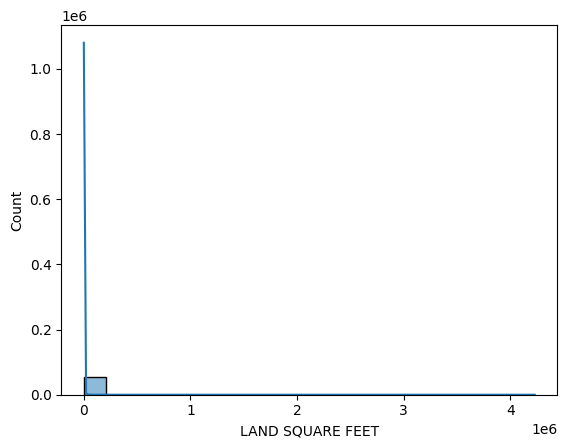

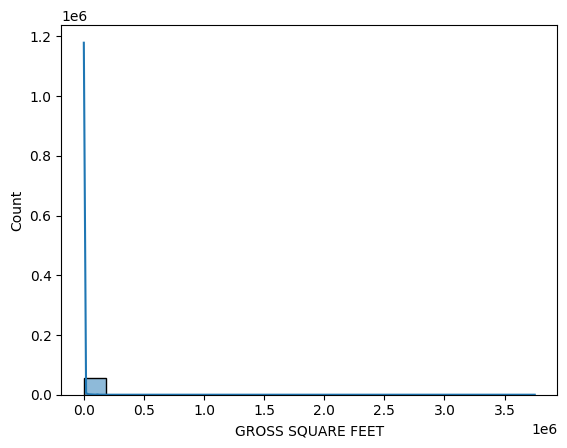

In [238]:

for col in df.select_dtypes(include=['number']).columns:
    if col in ['GROSS SQUARE FEET','LAND SQUARE FEET']:
        plt.figure()
        sns.histplot(data=df, x=col, bins=20, kde=True)
        plt.show()

Ya no hay datos nulos:

In [239]:
df.isnull().sum().sort_values(ascending=False)*100/df.shape[0]

BOROUGH                           0.0
NEIGHBORHOOD                      0.0
BUILDING CLASS CATEGORY           0.0
TAX CLASS AT PRESENT              0.0
BUILDING CLASS AT PRESENT         0.0
ADDRESS                           0.0
ZIP CODE                          0.0
RESIDENTIAL UNITS                 0.0
COMMERCIAL UNITS                  0.0
LAND SQUARE FEET                  0.0
GROSS SQUARE FEET                 0.0
YEAR BUILT                        0.0
TAX CLASS AT TIME OF SALE         0.0
BUILDING CLASS AT TIME OF SALE    0.0
SALE PRICE                        0.0
SALE DATE                         0.0
dtype: float64

### 2. Análisis exploratorio de variables categóricas:

a.	Identifiquen cuáles variables son nominales y cuáles son ordinales.

b.	Identifiquen las variables que no deberían incluirse en la matriz de características.

c.	Indiquen qué tipo de procesamiento debería recibir cada una de las variables categóricas, según su tipo y cardinalidad.

d.	Reporten los resultados de los análisis en una celda de texto.


Respuestas:

a.
- Las variables como ZIP CODE, BOROUGH, NEIGHBORHOOD, ADDRESS, BUILDING CLASS CATEGORY, BUILDING CLASS AT TIME OF SALE y BUILDING CLASS AT PRESENT son de tipo nominal, ya que representan categorías sin un orden inherente.

- Por otro lado, TAX CLASS AT PRESENT y TAX CLASS AT TIME OF SALE se consideran variable ordinales, debido a que sus valores reflejan una jerarquía en la clasificación fiscal.


b. Se elimina ADDRESS de la matriz de características ya que tiene muy alta cardinalidad con 57220 categorías distintas. Al usar groupby, el resto de variables presentan diferencias en la mediana (50%) al compararlas con SALE PRICE, por lo que pueden ser buenas predictoras.


c. Para las variables TAX CLASS AT PRESENT y TAX CLASS AT TIME OF SALE se usará OrdinalEncoder ya que tienen orden. Por otro lado para variables con alta cardinalidad como NEIGHBORHOOD, BUILDING CLASS AT PRESENT, ZIP CODE y BUILDING CLASS AT TIME OF SALE se usará OneHotEncoder limitando el número de categorías y filtrando según la mínima frecuencia. Para el resto de variables se utilizará OneHotEncoder sin restricciones ya que no tienen alta cardinalidad.

La variable de SALE DATE tiene alta cardinalidad porque casi todas son fechas distintas, entonces se divide la variable en SALE YEAR, SALE MONTH y SALE DAY



In [240]:
df['SALE DATE'] = pd.to_datetime(df['SALE DATE'])

df['SALE YEAR'] = df['SALE DATE'].dt.year
df['SALE MONTH'] = df['SALE DATE'].dt.month
df['SALE DAY'] = df['SALE DATE'].dt.day

df = df.drop(columns=['SALE DATE'])


# Analizando variables categóricas sin convertirlas a numéricas:
dfCategorical = df.copy()

dfCategorical['BOROUGH'] = dfCategorical['BOROUGH'].astype('str')
dfCategorical['ZIP CODE'] = dfCategorical['ZIP CODE'].astype('str')
dfCategorical['TAX CLASS AT TIME OF SALE'] = dfCategorical['TAX CLASS AT TIME OF SALE'].astype('str')




In [241]:
dfCategorical.describe(include='object').T

,count,unique,top,freq
BOROUGH,55213,5,4,17657
NEIGHBORHOOD,55213,253,FLUSHING-NORTH,2048
BUILDING CLASS CATEGORY,55213,46,01 ONE FAMILY DWELLINGS,12971
TAX CLASS AT PRESENT,55213,9,1,25558
BUILDING CLASS AT PRESENT,55213,148,D4,11323
ADDRESS,55213,47069,131-05 40TH ROAD,208
ZIP CODE,55213,184,10314,1137
TAX CLASS AT TIME OF SALE,55213,3,2,26652
BUILDING CLASS AT TIME OF SALE,55213,149,D4,11323


In [242]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55213 entries, 0 to 84547
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   BOROUGH                         55213 non-null  int64  
 1   NEIGHBORHOOD                    55213 non-null  object 
 2   BUILDING CLASS CATEGORY         55213 non-null  object 
 3   TAX CLASS AT PRESENT            55213 non-null  object 
 4   BUILDING CLASS AT PRESENT       55213 non-null  object 
 5   ADDRESS                         55213 non-null  object 
 6   ZIP CODE                        55213 non-null  int64  
 7   RESIDENTIAL UNITS               55213 non-null  int64  
 8   COMMERCIAL UNITS                55213 non-null  int64  
 9   LAND SQUARE FEET                55213 non-null  float64
 10  GROSS SQUARE FEET               55213 non-null  float64
 11  YEAR BUILT                      55213 non-null  int64  
 12  TAX CLASS AT TIME OF SALE       55213

In [243]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}")
    print(df.groupby(col)['SALE PRICE'].describe())

NEIGHBORHOOD
                    count          mean           std       min       25%  \
NEIGHBORHOOD                                                                
AIRPORT LA GUARDIA    5.0  6.875020e+05  5.569491e+05      10.0  275500.0   
ALPHABET CITY       138.0  2.671067e+06  6.919983e+06       1.0  510500.0   
ANNADALE            121.0  6.419686e+05  3.055128e+05      10.0  490000.0   
ARDEN HEIGHTS       241.0  3.944167e+05  1.225836e+05     100.0  324000.0   
ARROCHAR             30.0  5.763387e+05  2.673671e+05  200000.0  463500.0   
...                   ...           ...           ...       ...       ...   
WOODHAVEN           296.0  5.834879e+05  3.450788e+05      10.0  444125.0   
WOODLAWN             63.0  6.495611e+05  1.827626e+06      10.0  145250.0   
WOODROW              93.0  6.685325e+05  1.173677e+06      10.0  445000.0   
WOODSIDE            273.0  7.741803e+05  1.645010e+06       1.0  288000.0   
WYCKOFF HEIGHTS      46.0  1.342586e+06  1.091168e+06      10.0

### 3.	Análisis exploratorio de variables numéricas:

a.	Identifiquen variables que sean (aproximadamente) normales y otras que tengan una distribución diferente.

b.	Identifiquen variables con valores atípicos.

c.	Indiquen qué tipo de procesamiento debería recibir cada una de las variables numéricas, según su distribución y la presencia de valores atípicos.

d.	Reporten los resultados de los análisis en una celda de texto.


#### Respuestas: 
a. Al observar las gráficas ninguna variable es aproximadamente normal, pero puede deberse a valores atipicos.

b. Las variables RESIDENTIAL UNITS, COMMERCIAL UNITS, LAND SQUARE FEET, GROSS SQUARE FEET, SALE PRICE tienen datos atipicos.

c. Las variables RESIDENTIAL UNITS, COMMERCIAL UNITS, LAND SQUARE FEET, GROSS SQUARE FEET, YEAR BUILT, SALE PRICE requieren de un tratamiento de outliers. Para las variables LAND SQUARE FEET y GROSS SQUARE FEET se aplicará una transformación de Standard Scaler ya que luego de haber aplicado tratamiento de atipicos tienden a una forma un poco más normal. Para el resto de variables numéricas se aplicará Power Transformer ya que no muestran una distribución clara.

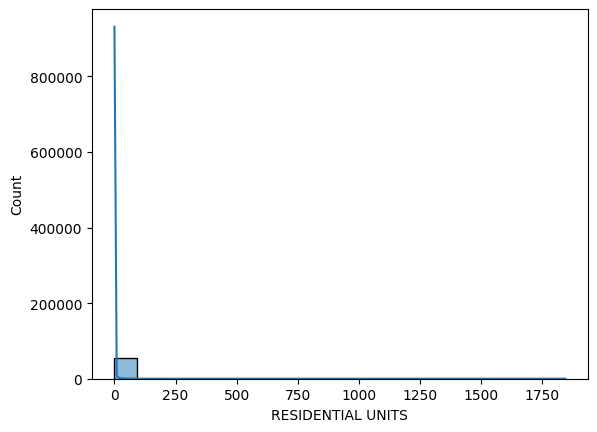

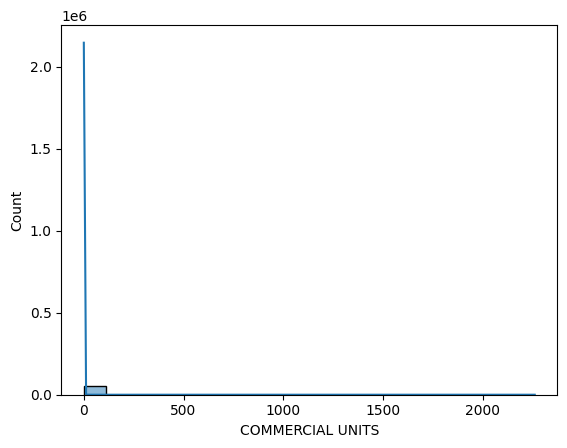

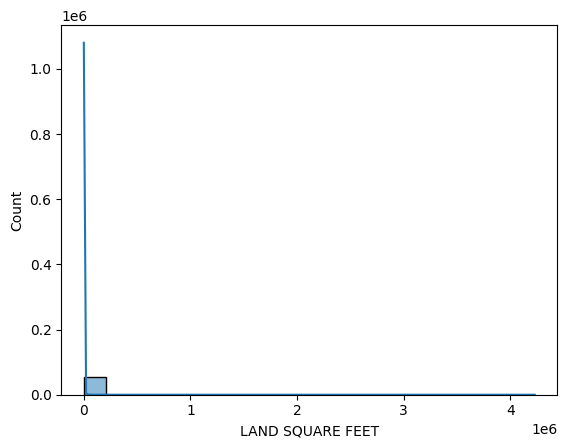

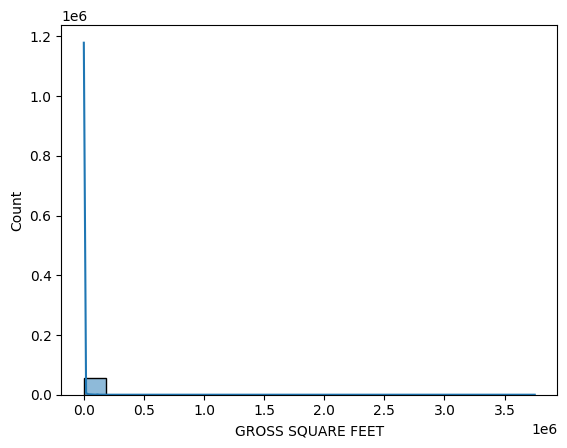

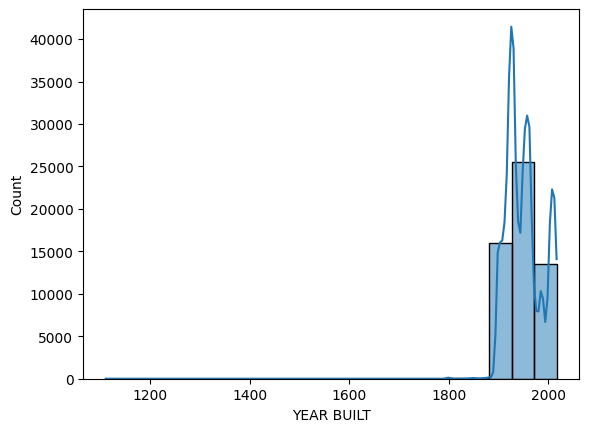

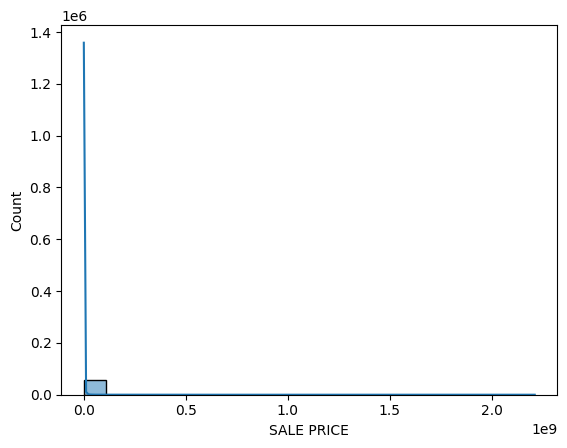

In [244]:
import matplotlib.pyplot as plt
import seaborn as sns

exclude_cols = ['BOROUGH', 'ZIP CODE', 'TAX CLASS AT TIME OF SALE', 'TAX CLASS AT PRESENT', 'BUILDING CLASS AT PRESENT','SALE MONTH','SALE DAY','SALE YEAR']

for col in df.select_dtypes(include=['number']).columns:
    if col in exclude_cols:
        continue
    plt.figure()
    sns.histplot(data=df, x=col, bins=20, kde=True)
    plt.show()

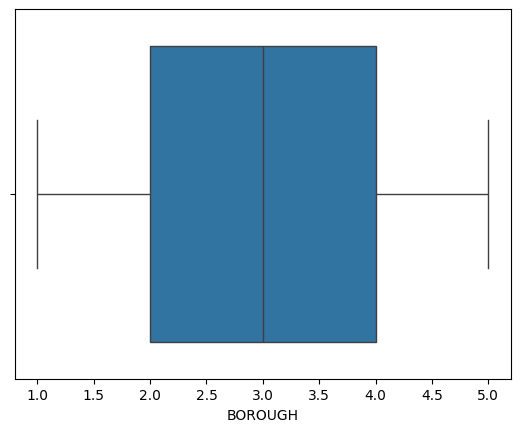

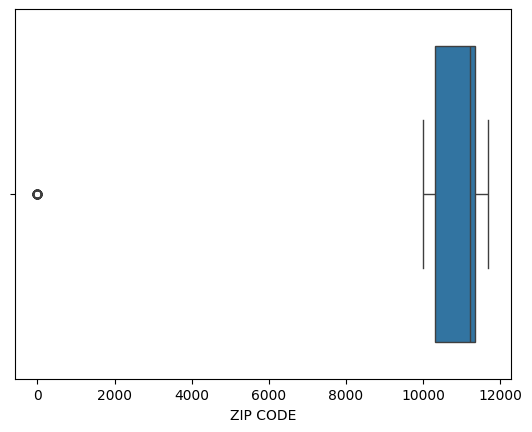

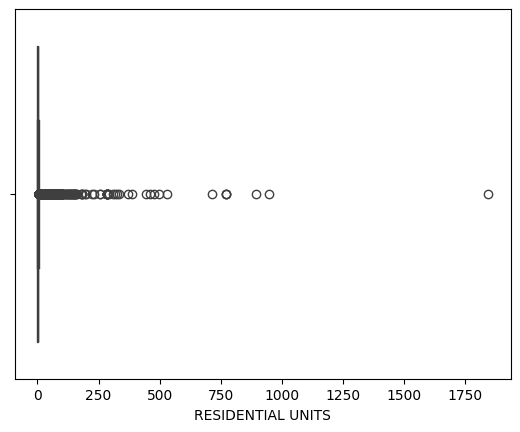

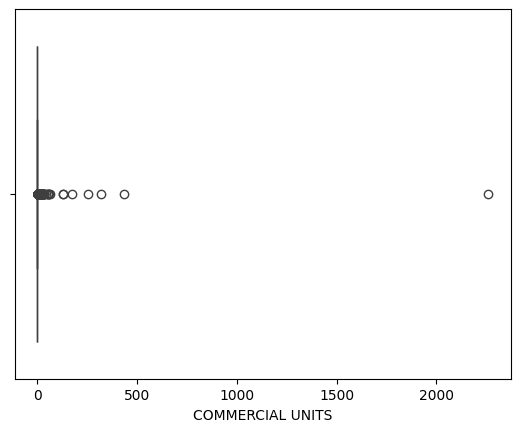

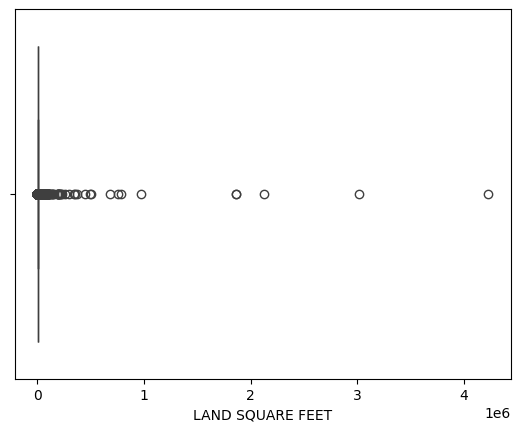

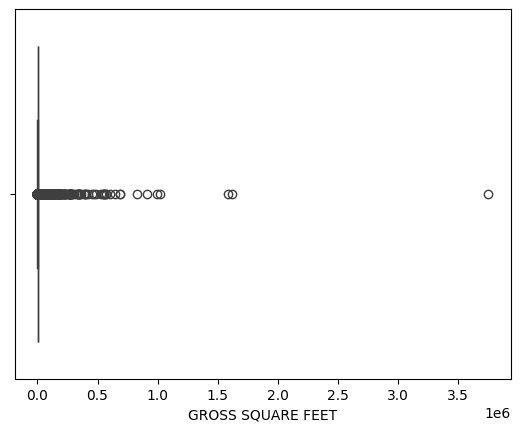

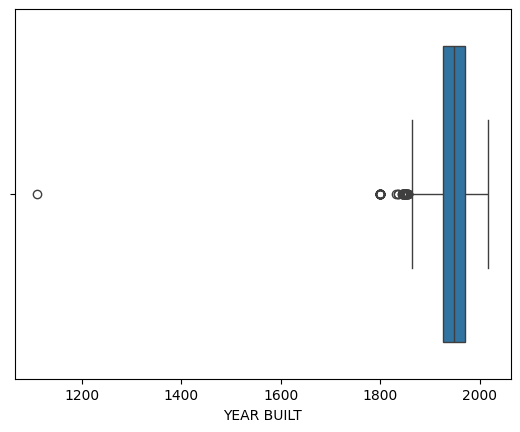

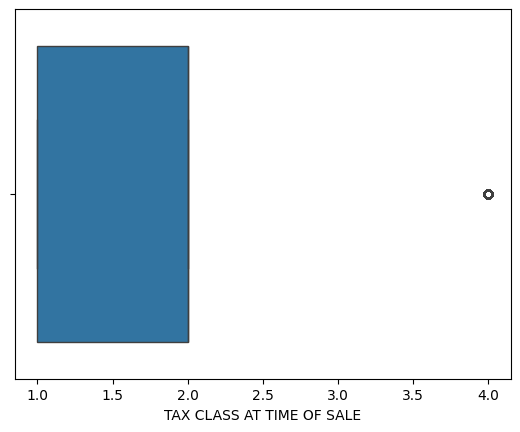

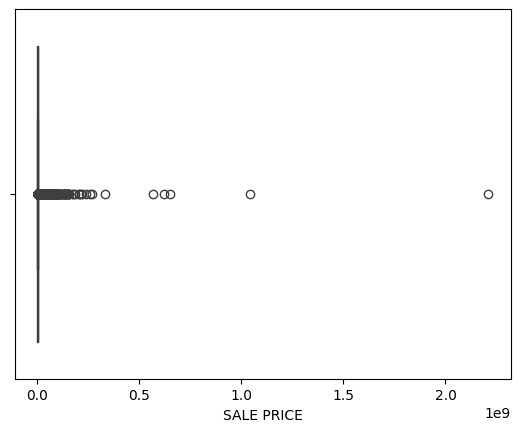

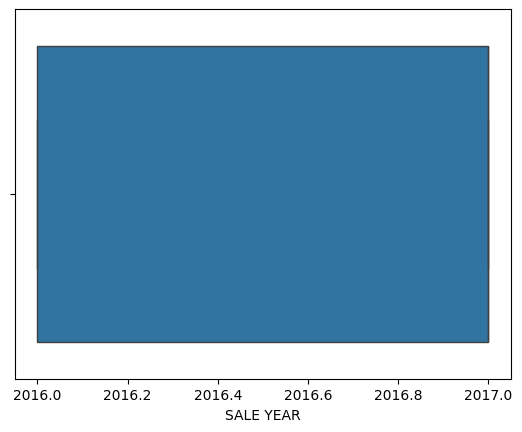

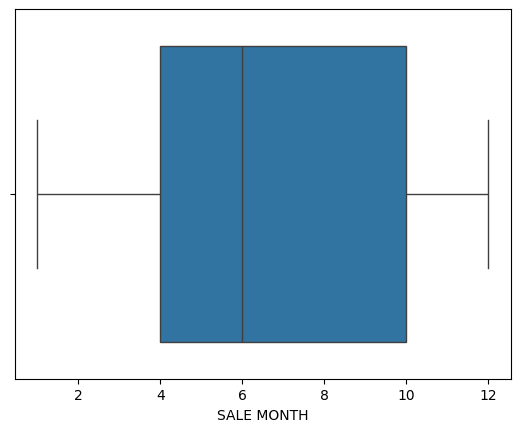

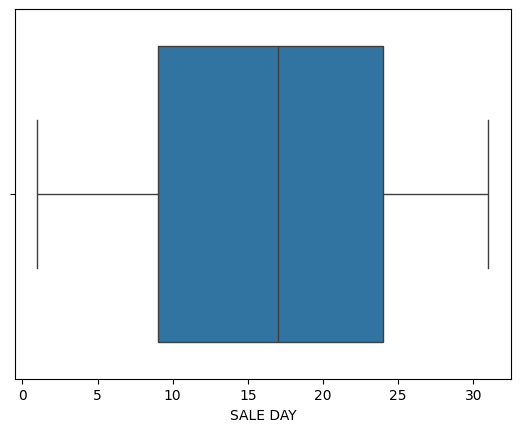

In [245]:
for num in df.select_dtypes(include=['number']).columns:
    plt.figure()
    sns.boxplot(data=df, x=num)
    plt.show();

In [246]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Asimetría de {num}: {df[num].skew():.3f} \n")

Asimetría de BOROUGH: -0.293 

Asimetría de ZIP CODE: -3.877 

Asimetría de RESIDENTIAL UNITS: 62.476 

Asimetría de COMMERCIAL UNITS: 208.924 

Asimetría de LAND SQUARE FEET: 105.437 

Asimetría de GROSS SQUARE FEET: 82.337 

Asimetría de YEAR BUILT: 0.130 

Asimetría de TAX CLASS AT TIME OF SALE: 1.417 

Asimetría de SALE PRICE: 116.153 

Asimetría de SALE YEAR: -0.662 

Asimetría de SALE MONTH: 0.004 

Asimetría de SALE DAY: -0.066 



In [247]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Kurtosis de {num}: {df[num].kurt():.3f} \n")

Kurtosis de BOROUGH: -1.130 

Kurtosis de ZIP CODE: 58.968 

Kurtosis de RESIDENTIAL UNITS: 5850.724 

Kurtosis de COMMERCIAL UNITS: 46537.135 

Kurtosis de LAND SQUARE FEET: 13152.957 

Kurtosis de GROSS SQUARE FEET: 10550.599 

Kurtosis de YEAR BUILT: 5.785 

Kurtosis de TAX CLASS AT TIME OF SALE: 3.124 

Kurtosis de SALE PRICE: 18307.213 

Kurtosis de SALE YEAR: -1.561 

Kurtosis de SALE MONTH: -1.199 

Kurtosis de SALE DAY: -1.169 



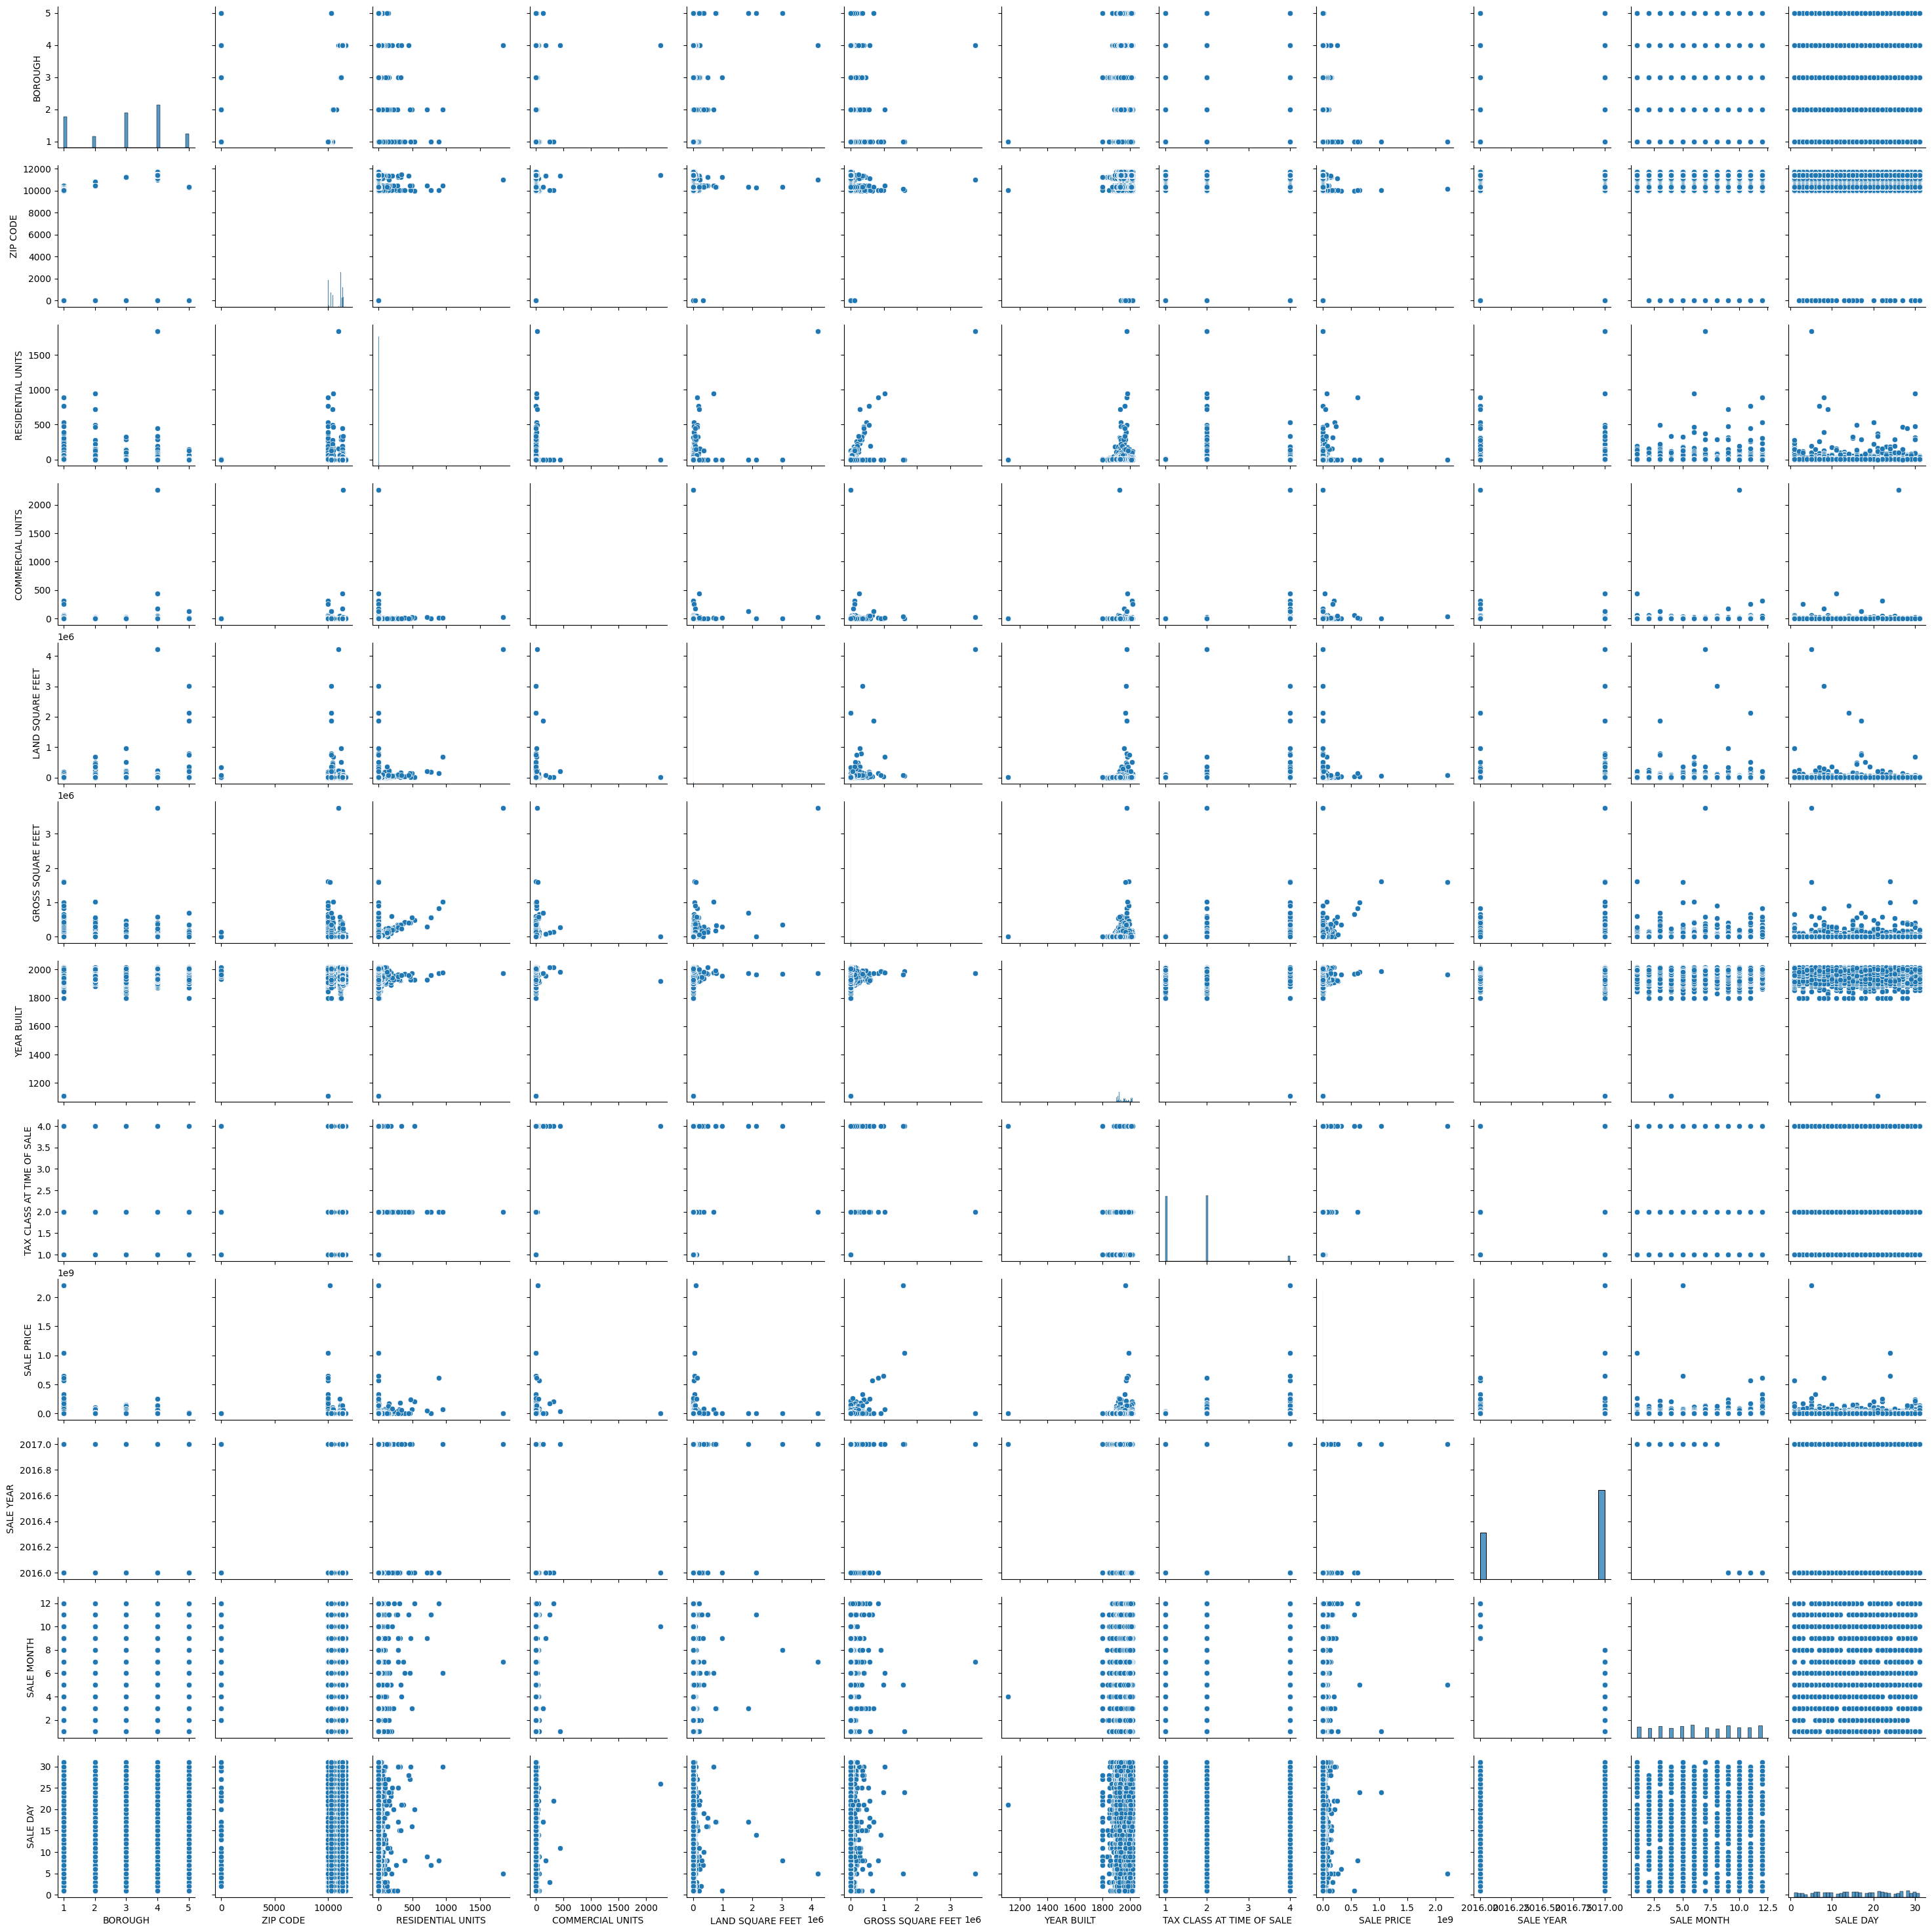

In [248]:
sns.pairplot(df.select_dtypes(include=['number']))

Tratando outliers se encontró que al usar el metodo del IQR se perdían demasiados datos, por ello se decidió dejar el resultado del tratamiento con percentiles.

In [249]:
df_iqr = df.copy()

numerical_cols = [
    'RESIDENTIAL UNITS',
    'COMMERCIAL UNITS',
    'LAND SQUARE FEET',
    'GROSS SQUARE FEET',
    'YEAR BUILT',
    'SALE YEAR',
    'SALE MONTH',
    'SALE DAY'
]

for col in numerical_cols:
    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_iqr = df_iqr[(df_iqr[col] >= lower) & (df_iqr[col] <= upper)]

print('Número de registros:', df_iqr.shape[0])

Número de registros: 20290


In [250]:
df_percentiles = df.copy()

numerical_cols = [
    'RESIDENTIAL UNITS',
    'COMMERCIAL UNITS',
    'LAND SQUARE FEET',
    'GROSS SQUARE FEET',
    'YEAR BUILT',
    'SALE YEAR',
    'SALE MONTH',
    'SALE DAY'
]

for col in numerical_cols:
    lower = df_percentiles[col].quantile(0.01)
    upper = df_percentiles[col].quantile(0.99)

    df_percentiles = df_percentiles[
        (df_percentiles[col] >= lower) & 
        (df_percentiles[col] <= upper)
    ]

print('Número de registros:', df_percentiles.shape[0])

Número de registros: 53133


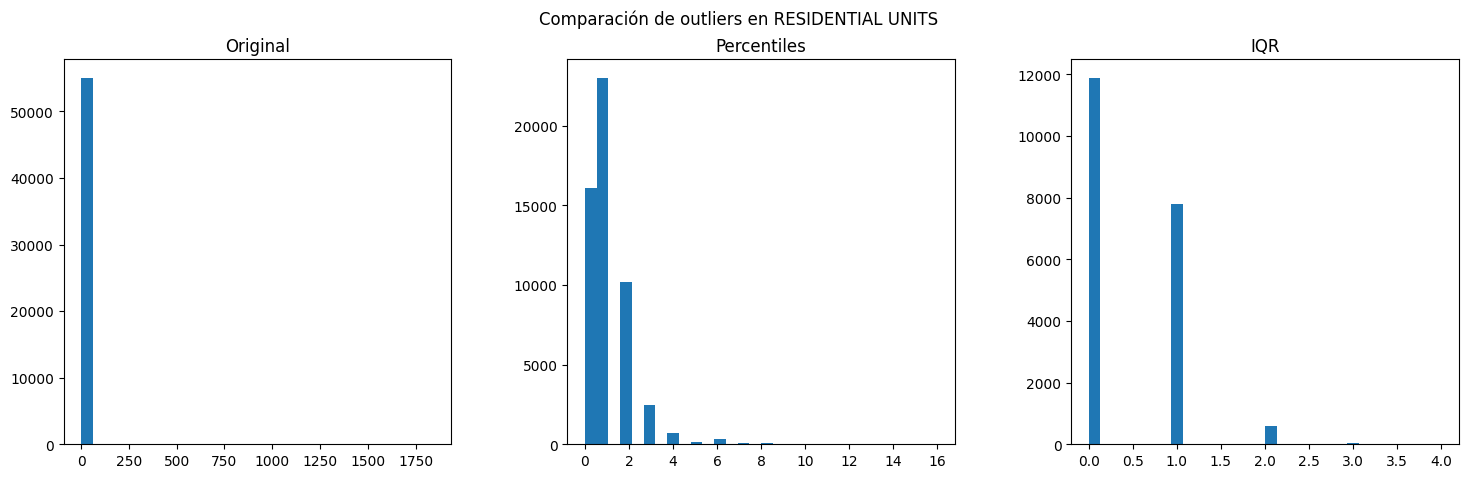

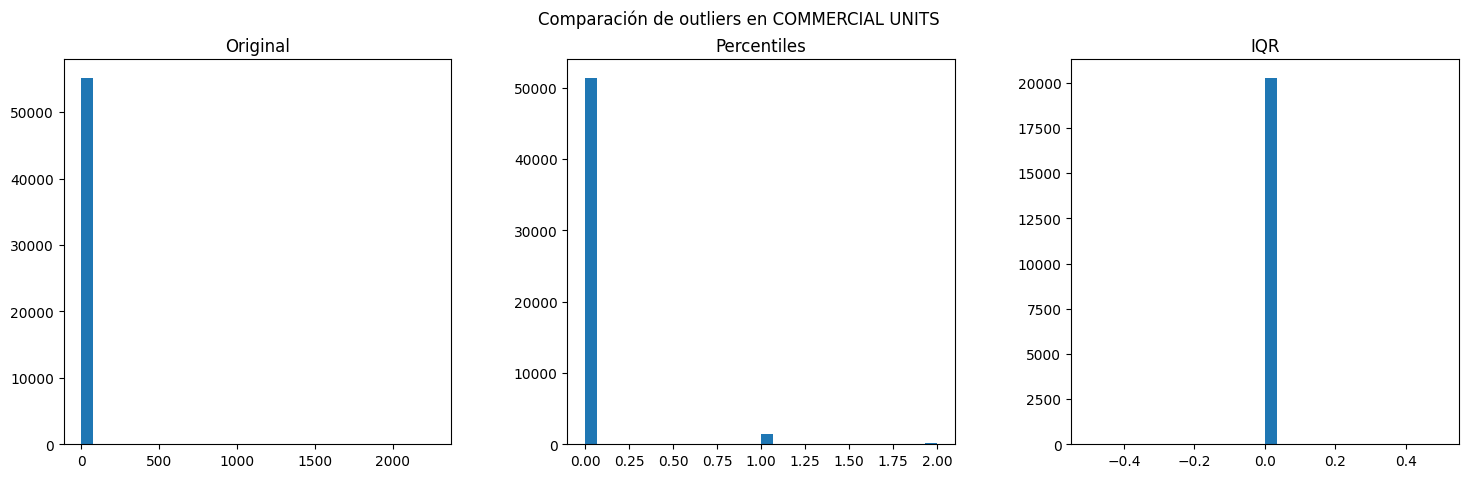

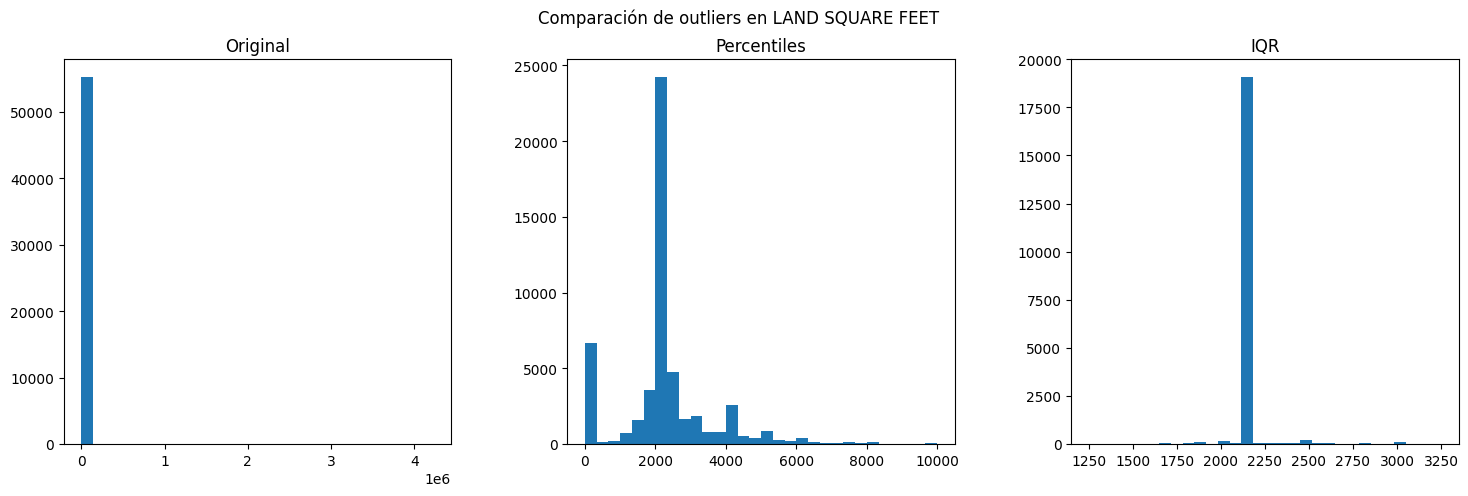

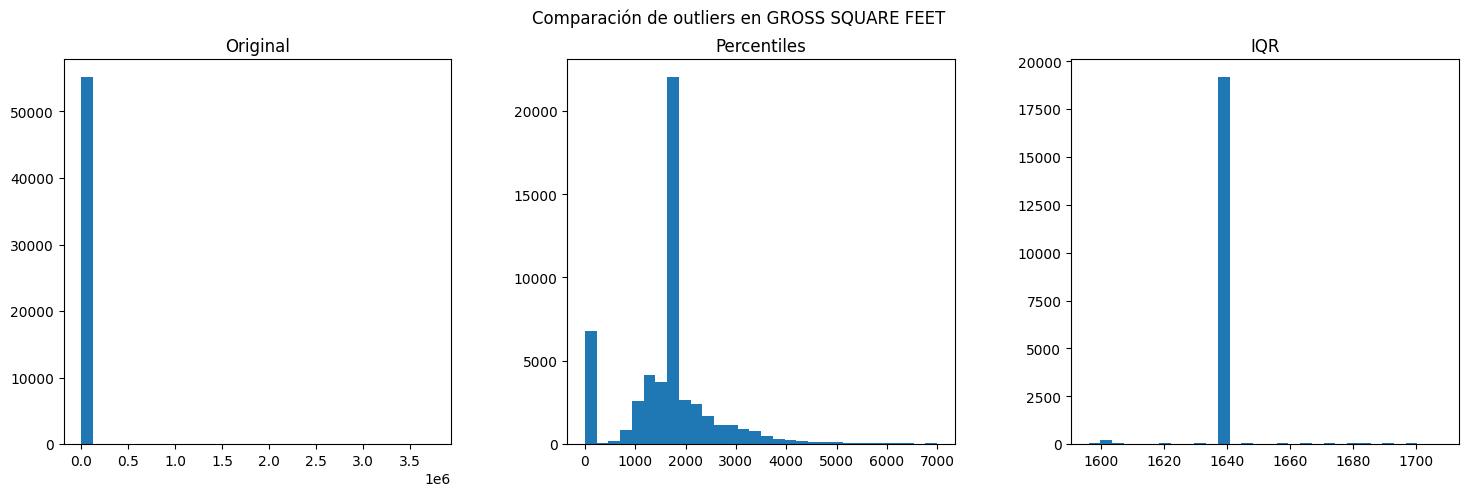

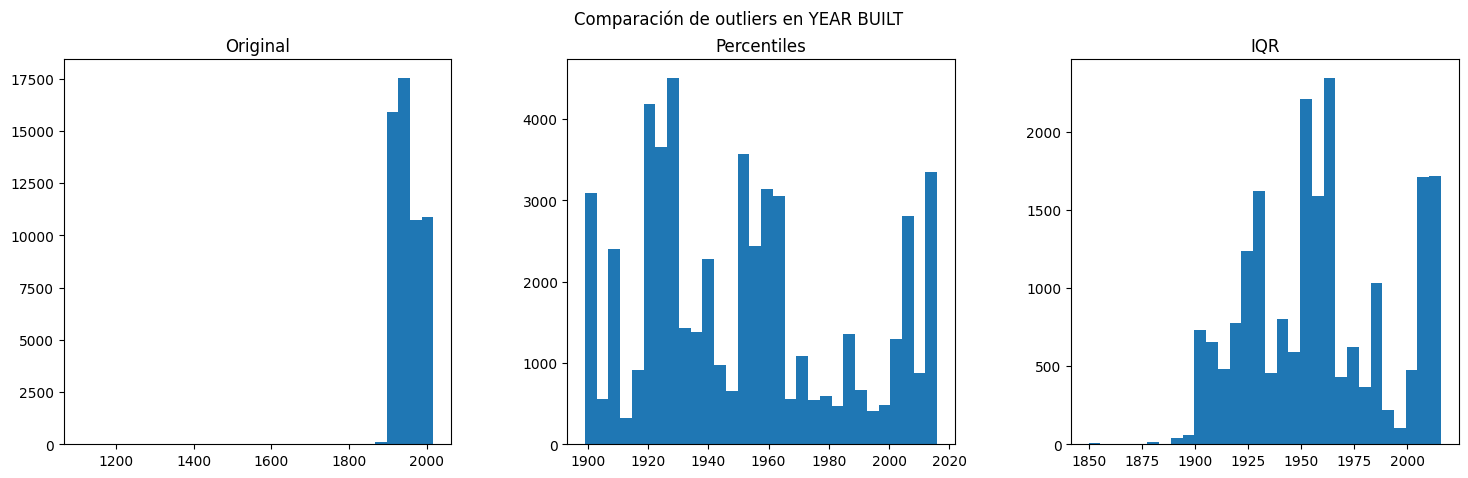

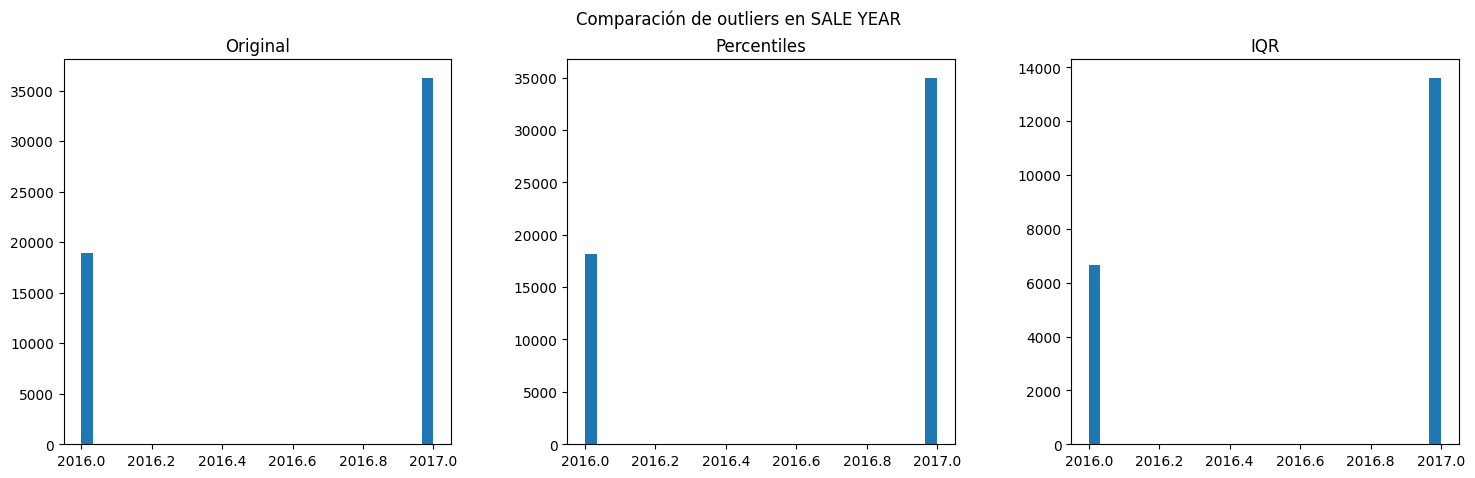

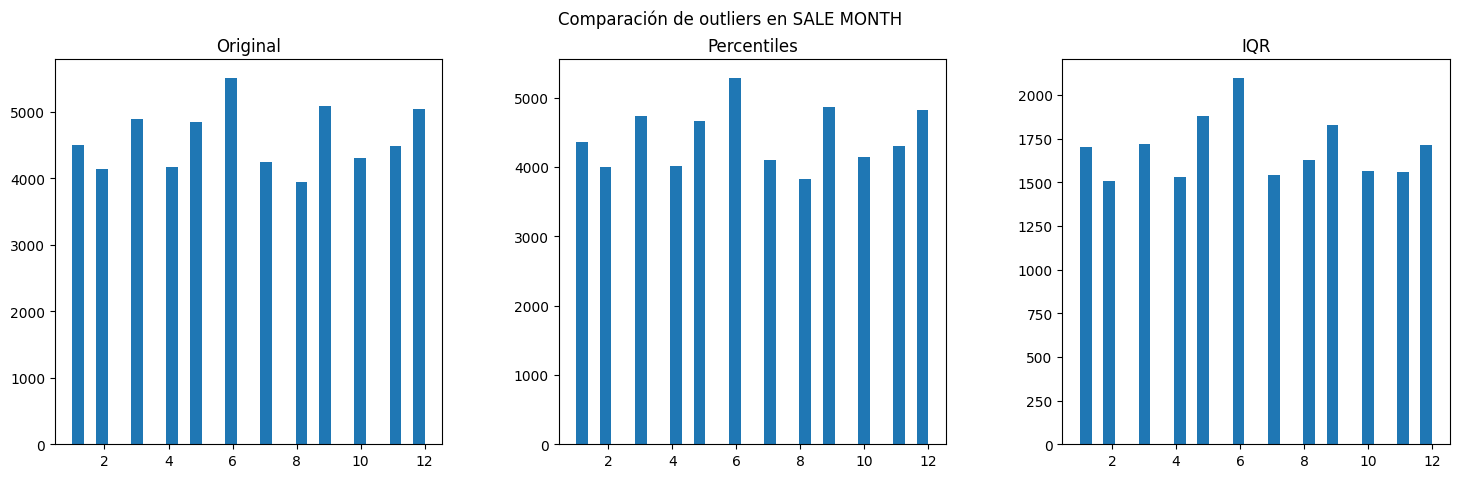

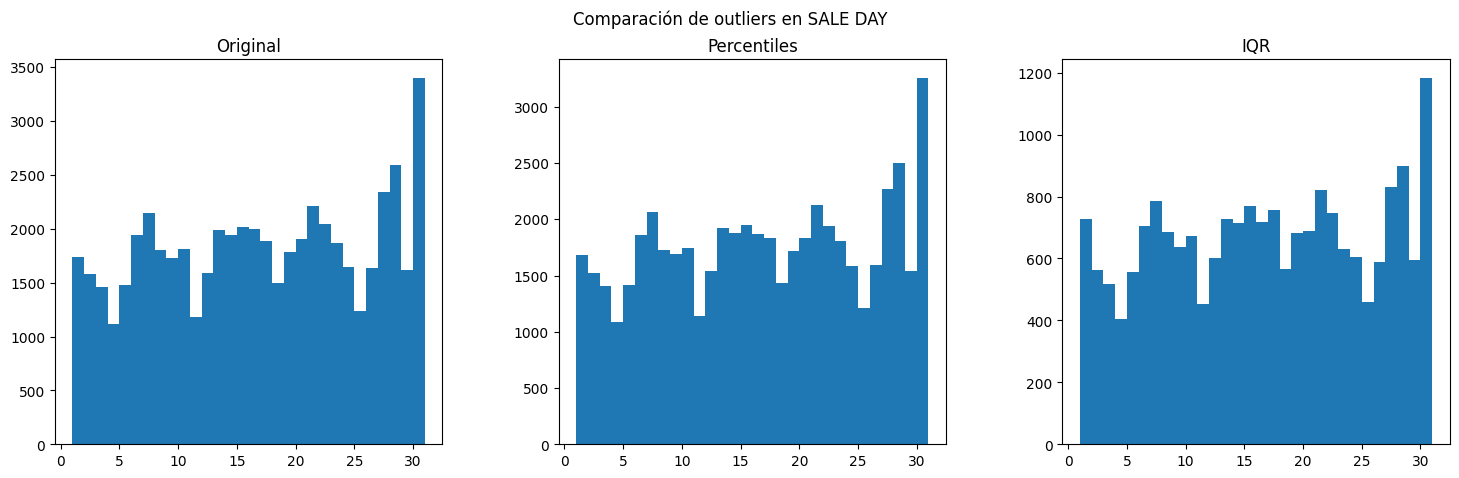

In [251]:


for col in numerical_cols:
    fig, ax = plt.subplots(1, 3, figsize=(18,5))
    fig.suptitle(f'Comparación de outliers en {col}')

    df.hist(col, bins=30, grid=False, ax=ax[0])
    ax[0].title.set_text('Original')

    df_percentiles.hist(col, bins=30, grid=False, ax=ax[1])
    ax[1].title.set_text('Percentiles')

    df_iqr.hist(col, bins=30, grid=False, ax=ax[2])
    ax[2].title.set_text('IQR')

    plt.show()

4.	Procesamiento de las características y entrenamiento del modelo:

a.	Escojan un modelo adecuado al tipo de variable que van a predecir (modelo de clasificación o de regresión)

b.	Extraigan la matriz de características y el vector objetivo de su dataframe, a partir de los análisis previos.

c.	Partan los datos en subconjuntos de entrenamiento y de prueba.

d.	Procesen las características del modelo usando ColumnTransformer.

e.	Entrenen el modelo.

f.	Reporten los scores de entrenamiento y de prueba.

g.	Reporten el listado completo de características con las que fue entrenado el modelo después del procesamiento realizado.


In [252]:
#Extrayendo matriz de características y vector objetivo
from sklearn.model_selection import train_test_split

df_percentiles.drop(columns=['ADDRESS'], inplace=True)

X = df_percentiles.drop(['SALE PRICE'], axis=1)
y = df_percentiles['SALE PRICE']

#Partiendo el dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.7)
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (37193, 16)
Tamaño del conjunto de prueba es: (15940, 16)


In [253]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, PowerTransformer

ss = StandardScaler() 
pt = PowerTransformer() 
ordenTaxPresent = ['1', '1A', '1B', '1C', '2', '2A', '2B', '2C', '3', '4']
ordenTaxTimeOfSale = ['1','2','3','4']

oreTaxPresent = OrdinalEncoder(categories=[ordenTaxPresent], dtype='int') 
oreTaxTimeOfSale = OrdinalEncoder(categories=[ordenTaxTimeOfSale], dtype='int') 
ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore' ) 


oheCardinalidad = OneHotEncoder(
    sparse_output=False,
    max_categories=15,
    min_frequency=500,
    handle_unknown='ignore'
    )

In [254]:
df_percentiles.columns

Index(['BOROUGH', 'NEIGHBORHOOD', 'BUILDING CLASS CATEGORY',
       'TAX CLASS AT PRESENT', 'BUILDING CLASS AT PRESENT', 'ZIP CODE',
       'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'LAND SQUARE FEET',
       'GROSS SQUARE FEET', 'YEAR BUILT', 'TAX CLASS AT TIME OF SALE',
       'BUILDING CLASS AT TIME OF SALE', 'SALE PRICE', 'SALE YEAR',
       'SALE MONTH', 'SALE DAY'],
      dtype='object')

In [255]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('num_prep', ss, ['LAND SQUARE FEET', 'GROSS SQUARE FEET']), # Escalado
    ('num_prep2', pt, ['RESIDENTIAL UNITS','COMMERCIAL UNITS','YEAR BUILT', 'SALE YEAR', 'SALE MONTH', 'SALE DAY']), # Transformación
    ('cod_taxPresent', oreTaxPresent, ['TAX CLASS AT PRESENT']), # Codificación ordinal
    ('cod_taxTimeOfSale', oreTaxTimeOfSale, ['TAX CLASS AT TIME OF SALE']), # Codificación ordinal
    ('cod_oh', ohe, ['BOROUGH','BUILDING CLASS CATEGORY']),
    ('cod_ohCardinalidad', oheCardinalidad, ['NEIGHBORHOOD', 'BUILDING CLASS AT PRESENT', 'ZIP CODE', 'BUILDING CLASS AT TIME OF SALE'])
    ], remainder='drop') # Las demás columnas se descartan

In [256]:
preprocessor

,transformers,"[('num_prep', ...), ('num_prep2', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [257]:
preprocessor.fit(X_train)
X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test)

c:\Users\pholc\Videos\2026_1\Analisis predictivo de datos\ap-2026-1-62\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [258]:
from sklearn.tree import DecisionTreeRegressor
#Usamos DecisionTreeRegressor porque la variable a predecir es numérica
tree = DecisionTreeRegressor(
    max_depth=5,
    random_state=1
)

tree.fit(X_train_prep, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [259]:
print(f'Score R^2 en el conjunto de entrenamiento: {tree.score(X_train_prep, y_train)}')
print(f'Score R^2 en el conjunto de prueba: {tree.score(X_test_prep, y_test)}')

Score R^2 en el conjunto de entrenamiento: 0.3758520369747317
Score R^2 en el conjunto de prueba: 0.07190316578371259


In [260]:
print(preprocessor.get_feature_names_out())

['num_prep__LAND SQUARE FEET' 'num_prep__GROSS SQUARE FEET'
 'num_prep2__RESIDENTIAL UNITS' 'num_prep2__COMMERCIAL UNITS'
 'num_prep2__YEAR BUILT' 'num_prep2__SALE YEAR' 'num_prep2__SALE MONTH'
 'num_prep2__SALE DAY' 'cod_taxPresent__TAX CLASS AT PRESENT'
 'cod_taxTimeOfSale__TAX CLASS AT TIME OF SALE' 'cod_oh__BOROUGH_2'
 'cod_oh__BOROUGH_3' 'cod_oh__BOROUGH_4' 'cod_oh__BOROUGH_5'
 'cod_oh__BUILDING CLASS CATEGORY_02 TWO FAMILY DWELLINGS                    '
 'cod_oh__BUILDING CLASS CATEGORY_03 THREE FAMILY DWELLINGS                  '
 'cod_oh__BUILDING CLASS CATEGORY_04 TAX CLASS 1 CONDOS                      '
 'cod_oh__BUILDING CLASS CATEGORY_05 TAX CLASS 1 VACANT LAND                 '
 'cod_oh__BUILDING CLASS CATEGORY_06 TAX CLASS 1 - OTHER                     '
 'cod_oh__BUILDING CLASS CATEGORY_07 RENTALS - WALKUP APARTMENTS             '
 'cod_oh__BUILDING CLASS CATEGORY_09 COOPS - WALKUP APARTMENTS               '
 'cod_oh__BUILDING CLASS CATEGORY_10 COOPS - ELEVATOR APARTMEN

In [261]:
print('El número de características con las que fue realmente entrenado el modelo son: ', preprocessor.get_feature_names_out().shape[0])

El número de características con las que fue realmente entrenado el modelo son:  103
